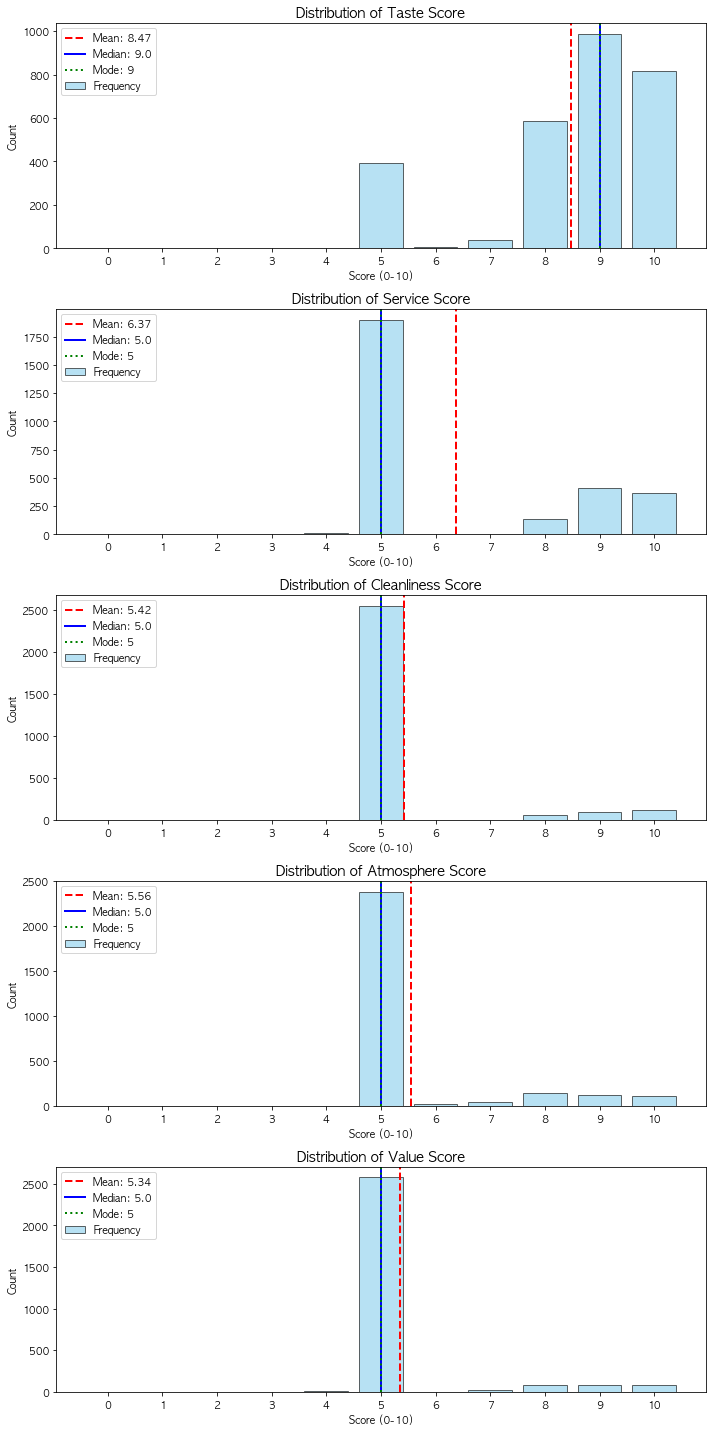

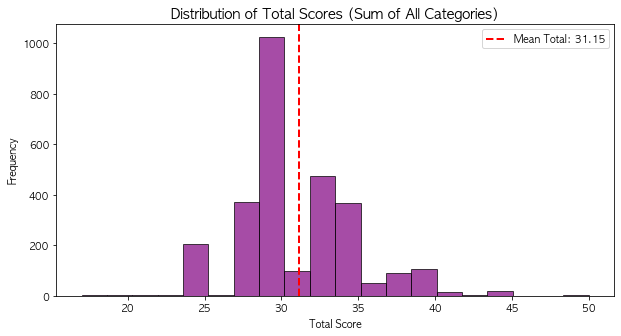

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# 1. Path setup
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
file_path = os.path.join(project_root, 'data', 'Review analysis', 'restaurant_analysis_top10_2.json')

if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    scores_df = pd.DataFrame([entry['scores'] for entry in data])
    categories = scores_df.columns
    
    # 2. Plot: Distribution with Mean, Median, Mode
    fig, axes = plt.subplots(len(categories), 1, figsize=(10, 4 * len(categories)))
    
    for i, category in enumerate(categories):
        ax = axes[i]
        counts = scores_df[category].value_counts().reindex(range(11), fill_value=0)
        
        mean_val = scores_df[category].mean()
        median_val = scores_df[category].median()
        mode_val = scores_df[category].mode()[0]
        
        ax.bar(counts.index, counts.values, color='skyblue', edgecolor='black', alpha=0.6, label='Frequency')
        
        # Add Statistics
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='blue', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')
        ax.axvline(mode_val, color='green', linestyle=':', linewidth=2, label=f'Mode: {mode_val}')
        
        ax.set_title(f'Distribution of {category.capitalize()} Score', fontsize=14, fontweight='bold')
        ax.set_xlabel('Score (0-10)')
        ax.set_ylabel('Count')
        ax.set_xticks(range(11))
        ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    # 3. Total Score Analysis
    scores_df['Total_Score'] = scores_df.sum(axis=1)
    
    plt.figure(figsize=(10, 5))
    plt.hist(scores_df['Total_Score'], bins=20, color='purple', edgecolor='black', alpha=0.7)
    plt.axvline(scores_df['Total_Score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean Total: {scores_df["Total_Score"].mean():.2f}')
    plt.title('Distribution of Total Scores (Sum of All Categories)', fontsize=14, fontweight='bold')
    plt.xlabel('Total Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
else:
    print(f"Error: File not found at {file_path}")


### 1. 카테고리별 점수 분포 분석

* **맛(Taste) - 압도적 우위:** 
  * 다른 지표들과 달리 8~10점대에 데이터가 집중됨.
  * 평균(8.47)과 중앙값(9.0)이 매우 높아, 고객들이 해당 식당의 맛에 대해서는 전반적으로 높은 만족도를 보임.


* **서비스, 청결, 분위기, 가성비 - 5점대 고착화:**
  * 4가지 항목 모두 최빈값(Mode)과 중앙값(Median)이 정확히 5점에 형성되어 있음.
  * 평가 시스템상 5점을 기본값으로 두어 발생하는 '응답 쏠림 현상(Central Tendency Bias)' - 언급 없으면 5점.



### 2. 총점(Total Score) 분포 분석
* 평균 총점은 31.15점으로, 각 항목당 평균 점수가 약 6점대 초반임을 의미함.
    * 총점이 30점 미만인 데이터도 상당수 존재함.

* 맛 점수는 8~9점대로 높지만, 나머지 항목들의 낮은 점수가 총점을 희석시키고 있음.




### Heatmap & SD Histogram

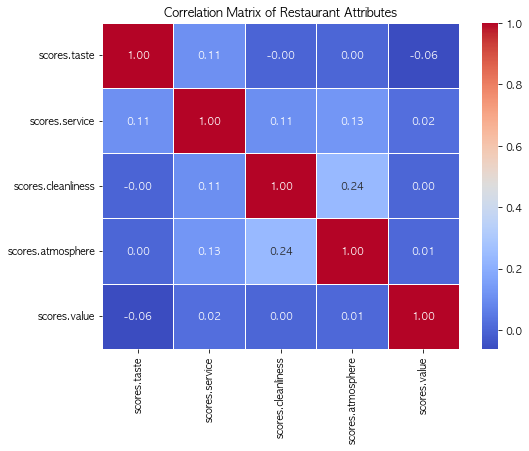

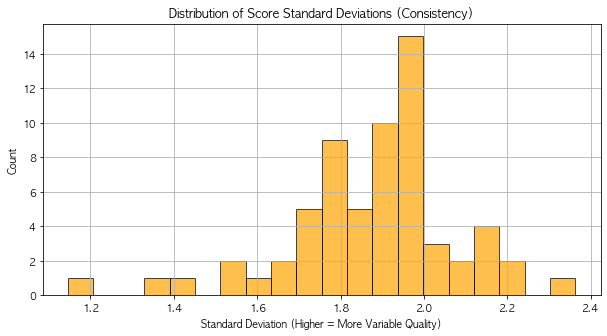

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

# 1. 데이터 로드 및 res_df 생성 (에러 방지용)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
file_path = os.path.join(project_root, 'data', 'Review analysis', 'restaurant_analysis_top10_2.json')

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# res_df 정의
res_df = pd.json_normalize(data)

# 2. 히트맵 그리기
plt.figure(figsize=(8, 6))
# 데이터프레임 내 컬럼명 확인 후 필요시 수정 (이미지 분석 결과 컬럼명이 'scores.taste' 형태라면 아래 코드가 맞습니다)
heatmap_data = res_df[['scores.taste', 'scores.service', 'scores.cleanliness', 'scores.atmosphere', 'scores.value']]
sns.heatmap(heatmap_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Restaurant Attributes')
plt.show()

# 3. 항목별 표준편차(Consistency) 확인
# 각 리뷰의 점수들 사이의 편차를 계산하여 'score_std' 컬럼 생성
score_cols = ['scores.taste', 'scores.service', 'scores.cleanliness', 'scores.atmosphere', 'scores.value']
res_df['score_std'] = res_df[score_cols].std(axis=1)

# 식당별 평균 편차 확인
consistency_df = res_df.groupby('restaurant_name')['score_std'].mean().sort_values()

plt.figure(figsize=(10, 5))
consistency_df.hist(bins=20, color='orange', edgecolor='black', alpha=0.7)
plt.title('Distribution of Score Standard Deviations (Consistency)')
plt.xlabel('Standard Deviation (Higher = More Variable Quality)')
plt.ylabel('Count')
plt.show()

### 1. 히트맵(Correlation Matrix) 분석

* **독립적인 평가 항목:**
  * 전체적인 상관계수가 대각선 성분(1.00)을 제외하고는 거의 0. 
    * 각 평가 항목(맛, 서비스, 청결, 분위기, 가성비)이 서로 강한 선형 관계를 맺고 있지 않음.
    * 맛이 좋다고 해서 반드시 서비스나 분위기 점수가 높은 것은 아님.
* 청결도 - 분위기
  * 유일하게 `scores.cleanliness`와 `scores.atmosphere` 사이의 상관계수가 **0.24**로 상대적으로 높음.
  * 고객들이 식당의 청결 상태와 분위기를 어느 정도 연관 지어 평가하는 경향이 있음.


### 2. 표준편차 히스토그램 분석 (일관성(Consistency) 측정)

* **정규 분포 형태:** 
  * 데이터가 1.9~2.0 구간을 중심으로 좌우 대칭에 가까운 정규 분포 형태. 
  * 이는 샘플링이 충분히 이루어져 데이터의 신뢰도가 이전보다 훨씬 높아졌음을 의미.
* 표준편차 1.9 이상 
  * 동일한 식당임에도 불구하고 고객마다 느끼는 점수 차이가 큼. 



### 레이더차트 (Top10)

/var/folders/tk/zzshctl57tl8x_wn7tn7lr7m0000gn/T/ipykernel_91218/2508880467.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(["2", "4", "6", "8", "10"], color="grey", size=8)


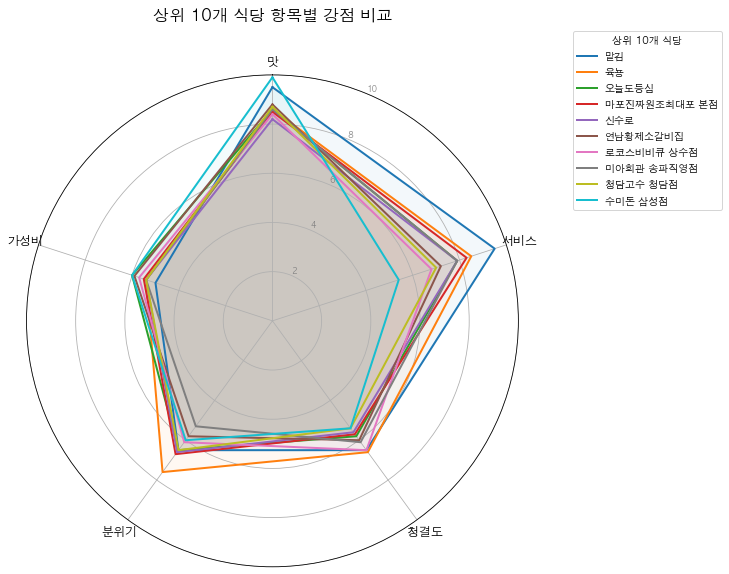

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import matplotlib as mpl

# 한글 폰트 설정
mpl.rc('font', family='AppleGothic')
mpl.rc('axes', unicode_minus=False)

# 1. 경로 설정 (프로젝트 루트 기준으로 데이터 로드)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
ranking_path = os.path.join(project_root, 'data', 'Review analysis', 'restaurant_ranking_2838_2.json')

# 2. 데이터 로드
with open(ranking_path, 'r', encoding='utf-8') as f:
    ranking_data = json.load(f)

df_rank = pd.DataFrame([{'name': item['restaurant_name'], **item['scores']} for item in ranking_data])
categories = ['taste', 'service', 'cleanliness', 'atmosphere', 'value']
N = len(categories)

# 각도 계산
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # 차트를 닫기 위한 마지막 각도

# 3. 레이더 차트 그리기 
plt.figure(figsize=(10, 8))
ax = plt.subplot(111, polar=True)

# 차트 중앙 정렬
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# [가장 확실한 방법] thetagrids 사용
# 각도(angles[:-1])에 맞는 라벨을 직접 지정합니다.
labels = ['맛', '서비스', '청결도', '분위기', '가성비']
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)

# 각 식당별 선 그리기
for i, row in df_rank.iterrows():
    vals = row[categories].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=row['name'])
    ax.fill(angles, vals, alpha=0.05)

# 범위 및 눈금
plt.ylim(0, 10)
# y축 눈금 라벨
ax.set_yticklabels(["2", "4", "6", "8", "10"], color="grey", size=8)

plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.1), title="상위 10개 식당")
plt.title('상위 10개 식당 항목별 강점 비교', size=16, y=1.1)

plt.tight_layout()
plt.show()

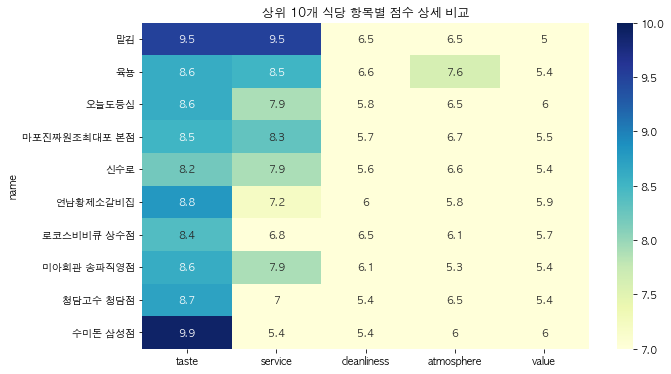

In [18]:
# 2. 전체 상위 10개 식당 히트맵 
plt.figure(figsize=(10, 6))
sns.heatmap(df_rank.set_index('name'), annot=True, cmap='YlGnBu', vmin=7, vmax=10)
plt.title('상위 10개 식당 항목별 점수 상세 비교')
plt.show()

**핵심 지표 편향성**
* 모든 식당에서 `taste` 항목이 압도적으로 높게 나타나며, 전반적으로 8.5~9.9 사이의 분포를 보임.
* 반면, `service`, `cleanliness`, `atmosphere`, `value` 항목들은 상대적으로 낮은 점수대(5~7점대)에 머물러 있음.
  * 이는 상위 식당으로 선정된 기준이 주로 '맛'에 크게 의존하고 있음을 의미함.


**항목별 특징**
* **맛(Taste):** 가장 높은 점수를 기록 중이며, 특히 '수미톤 삼성점'은 9.9점으로 최고 수준의 맛 점수를 보유함.
* **서비스(Service):** '맛' 다음으로 높은 점수를 기록하고 있으나, 상위권 식당들조차 5.4~9.5점까지 편차가 매우 큼.
* **기타 항목(Cleanliness, Atmosphere, Value):** 전반적으로 5~6점대에 정체되어 있어 식당 간 변별력이 낮음.

